# Week 9 - Introduction to Neural Networks

**Student Name 1, Student Name 2**

### Aims

The main concepts covered in this notebook are: 

>* getting familiar with the basics of keras
>* input-output with keras
>* construction of neural network models with keras

This week, we will be exploring the basics of keras and building and fitting our first neural network with keras. For a quick introduction, please see https://keras.io/getting_started/intro_to_keras_for_engineers/

When completing worksheets:

>- You will have tasks tagged by (CORE) and (EXTRA). 
>- Your primary aim is to complete the (CORE) components during the WS session, afterwards you can try to complete the (EXTRA) tasks for your self-learning process. 

Instructions for submitting your workshops can be found at the end of worksheet. As a reminder, you must submit a pdf of your notebook on Learn by 16:00 PM on the Friday of the week the workshop was given.

# Setup <a id='setup'></a>

## Packages

Let's load the some of the packages needed for this workshop. 

In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

# Part 1: Simulated Data

In the first part of this workshop, we will work with a simple simulated example to gain some basic understanding of neural networks and keras.

We generate $N=2000$ simulated data points. First we generate the labels assuming that:
$$  y_i \sim \text{Bern}(0.5).$$
Next, we generate the features of dimension $D=2$. The first feature is simulated uniformly in $[-\pi,\pi]$
$$x_{i,1} \sim \text{Uniform}(-\pi,\pi).$$
For the second feature, if $y=0$, then
$$x_{i,2} \sim \text{Norm}(\cos( x_{i,1}),\sigma^2).$$
Otherwise, if $y=1$, then
$$x_{i,2} \sim  \text{Norm}(1+ \cos( x_{i,1}),\sigma^2).$$

In [2]:
# Generate data
keras.utils.set_random_seed(11205)
N = 2000
D = 2
y = np.random.binomial(1, 0.5, N)
X = np.zeros((N, D))
X[:,0] = np.random.uniform(-np.pi, np.pi, N)
X[y == 0,1] = np.cos(X[y == 0,0]) + np.random.normal(0, 0.25, (y == 0).sum())
X[y == 1,1] = 1 + np.cos(X[y == 1,0]) + np.random.normal(0, 0.25, (y == 1).sum())

### 🚩 Exercise 1 (CORE)

Plot the data colored by the class labels. 

**EXTRA.** Derive the true decision boundary and add it to the plot. 

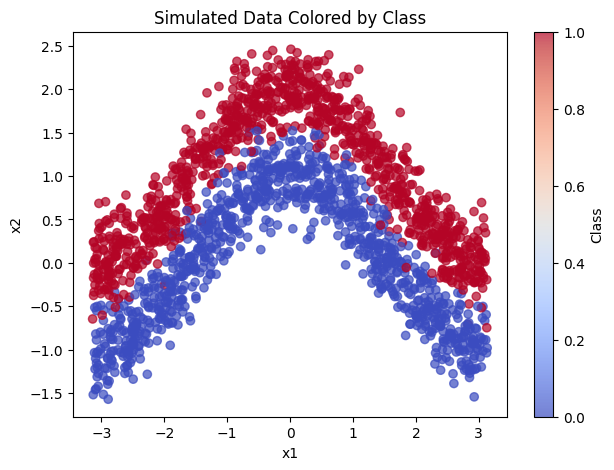

In [3]:
# Code for your answer here!
plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Simulated Data Colored by Class")
plt.colorbar(label="Class")
plt.show()

**EXTRA.** Type your answer here

## Building a baseline logistic regression in keras

Let's start by building a logistic regression model in keras, using the `Functional` model: https://keras.io/guides/functional_api/ 

A `Functional` model provides a way to build a directed graph of `Layers` that connect to each other. `Layers` are the basic building blocks of neural networks in keras:  https://keras.io/api/layers/

To construct a logistic regression model, we only need two layers: 
- an input layer, which we construct using an `Input` layer: https://keras.io/api/layers/core_layers/input/ 
- an output layer, which we construct using a `Dense` layer: https://keras.io/api/layers/core_layers/dense/

In [4]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
logit_layer = keras.layers.Dense(1, activation='sigmoid')

Then, we combine the layers and create our model which connects the input and output. 

In [5]:
output = logit_layer(input_layer)
model_lr = keras.models.Model(input_layer, output)
model_lr.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Print the number of layers in the model
print(len(model_lr.layers)) 

2


Alternatively, we can build the model using the `Sequential` model, see https://keras.io/api/models/sequential/ and https://keras.io/guides/sequential_model/. A `Sequential` model is esssentially a plain stack of `Layers` where each layer has exactly one input tensor and one output tensor, while a `Functional` model allows more general constructions (i.e. a graph of layers). 

In [7]:
model_lr2 = keras.Sequential(
    [
        keras.Input(shape=(D,)),
        keras.layers.Dense(1, activation='sigmoid'),
    ]
)
model_lr2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Now, we are ready to compile the model: https://keras.io/api/models/model_training_apis/

When compiling, we need to specify:
- a loss function: https://keras.io/api/losses/
- an optimizer: https://keras.io/api/optimizers/
- (optionally) metrics: https://keras.io/api/metrics/

In [8]:
model_lr.compile(
    loss='binary_crossentropy', # or loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam', # or  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
       keras.metrics.BinaryAccuracy(name='accuracy'),
       keras.metrics.AUC(name='auc')
    ],
)

### Training the model

Now, we are ready to to fit the model! We need to specifiy: 
- the number of `epochs` (which is the number of times that we cycle through the whole training data during gradient descent), 

and optionally various other parameters, such as 

- `shuffle` (e.g. `shuffle=True`), which specifies whether to shuffle the training data before each epoch.
- `validation_split` which is a float between 0 and 1, determining the fraction of the training data to be used as validation data. The model will set apart this fraction of the training data, will not train on it, and will evaluate the loss and any model metrics on this data at the end of each epoch. This is useful for **early stopping**, i.e. determining if training should be stopped early to prevent overfitting.
- `batch_size`: Integer or None. Number of samples per gradient update. If unspecified, batch_size will default to 32. 
For more details, see: https://keras.io/api/models/model_training_apis/

**Caution:** the data is not shuffled before splitting the data into a validation set. If the data are ordered in particular way when stored, then the training and validation sets can potentially characterize different populations. Thus, it is recommend to first shuffle the order of your data before fitting.  

In [9]:
# If you need to shuffle the data before fitting uncomment the following lines
# from sklearn.utils import shuffle
# X, y = shuffle(X, y, random_state=11205)

In [10]:
model_lr.fit(x=X, y=y, epochs=50, shuffle=True, validation_split=0.1)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5272 - auc: 0.5536 - loss: 0.8589 - val_accuracy: 0.5250 - val_auc: 0.5678 - val_loss: 0.8517
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5344 - auc: 0.5721 - loss: 0.8220 - val_accuracy: 0.5350 - val_auc: 0.5887 - val_loss: 0.8177
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5389 - auc: 0.5955 - loss: 0.7877 - val_accuracy: 0.5300 - val_auc: 0.6126 - val_loss: 0.7864
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5411 - auc: 0.6241 - loss: 0.7562 - val_accuracy: 0.5300 - val_auc: 0.6355 - val_loss: 0.7576
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5472 - auc: 0.6561 - loss: 0.7275 - val_accuracy: 0.5250 - val_auc: 0.6572 - val_loss: 0.7315
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5483 - auc: 0.6863 - loss: 0.7014 - val_accuracy: 0.5150 - val_auc: 0.6845 - val_loss: 0.7080
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step -

Let's plot the metrics as a function of the number of epochs.

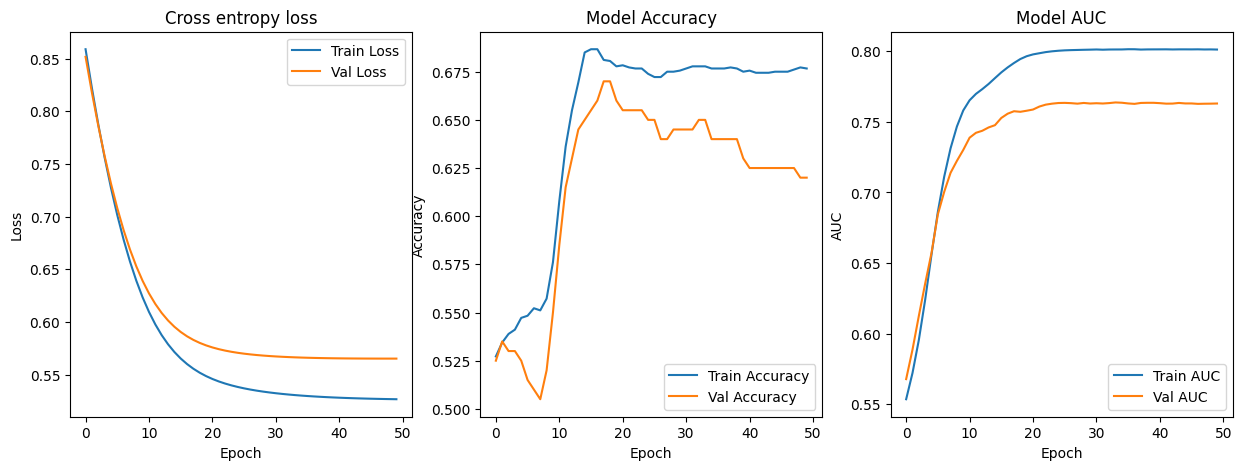

In [11]:
# Plot the training history
history = model_lr.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['accuracy'], label='Train Accuracy')
ax[1].plot(history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[2].plot(history['auc'], label='Train AUC')
ax[2].plot(history['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()
plt.show()

If you notice that the validation loss (and metrics) is still decreasing (increasing) as a function of epochs, this suggests that you may need to train the model longer.

If you notice that the validation loss (and metrics) starts to increase (decrease) as a function of epochs, this suggests that the model is starting to overfit. Based on this, we can determine the number of epochs to use based on the U-shape of the validation loss (this is known as early stopping, for more info see: https://keras.io/api/callbacks/early_stopping/). 

### Testing the model

Now, we can use `.predict()` to make predictions. Let's predict at a grid of test points and draw a heatmap of the predicted probabilities.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step


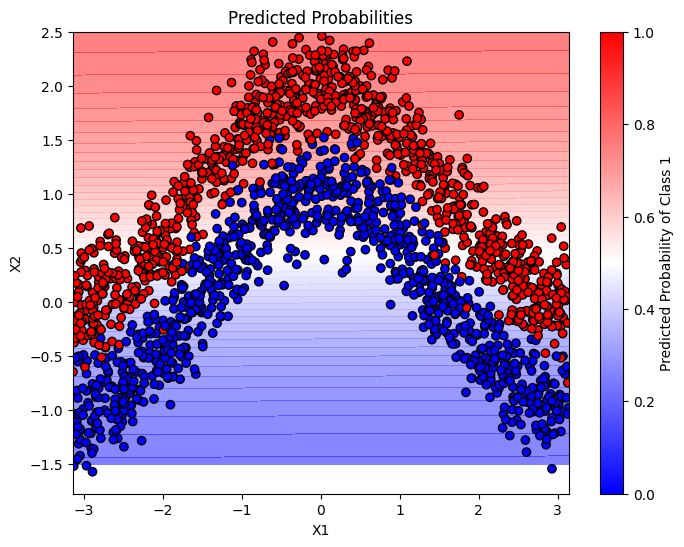

In [12]:
# Create a grid of test points
X_grid1, X_grid2 = np.meshgrid(np.linspace(-np.pi, np.pi, 100), np.linspace(-1.5, 2.5, 100))
X_grid = np.column_stack([X_grid1.ravel(), X_grid2.ravel()])

# Predict probabilities 
y_pred_prob_lr = model_lr.predict(X_grid)

# Draw a heatmap of the predicted probabilities
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob_lr.reshape(X_grid1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted Probabilities')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

### 🚩 Exercise 2 (CORE)

- Generate 1000 test data points from the same data generating process used to generated the training data.
- Compute the `classification_report` and `confusion_matrix`
- Is the result what you expect, and why?

In [ ]:
# Code for your answer here!
# 1. Generate 1000 test data points using the SAME data generating process
N_test = 1000
y_test = np.random.binomial(1, 0.5, N_test)
X_test = np.zeros((N_test, 2))

X_test[:,0] = np.random.uniform(-np.pi, np.pi, N_test)

X_test[y_test == 0, 1] = np.cos(X_test[y_test == 0, 0]) + np.random.normal(0, 0.25, (y_test == 0).sum())
X_test[y_test == 1, 1] = 1 + np.cos(X_test[y_test == 1, 0]) + np.random.normal(0, 0.25, (y_test == 1).sum())

# 2. Predict using your trained model
y_pred_prob = model_lr.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 3. Compute metrics
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.68      0.64      0.66       498
           1       0.66      0.70      0.68       502

    accuracy                           0.67      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       0.67      0.67      0.67      1000

[[317 181]
 [150 352]]


The results are generally as expected. The test data were generated using the same data‑generating process as the training data, which means the training and test sets follow the same underlying distribution. Because of this, the model is evaluated on data that are statistically similar to what it has already learned from, so its performance on the test set should be close to its performance during training.

Any misclassifications that appear are mainly due to the overlap and noise in the data. The two classes are not perfectly separable, and the added Gaussian noise around the cosine curves creates regions where the classes mix. A logistic regression model is also linear, so it cannot fully capture the nonlinear structure of the true decision boundary. Therefore, some errors are expected, especially near the boundary where the classes are harder to distinguish.

Overall, the performance is reasonable and consistent with what we would expect given the data‑generating mechanism and the limitations of the model.

### Adding a hidden layer

Now, let's add a hidden layer, with 2 neurons.

In [17]:
input_layer = keras.Input(shape=(D,))
hidden_layer = keras.layers.Dense(2, activation='relu')(input_layer)
output_layer = keras.layers.Dense(1, activation='sigmoid')(hidden_layer)
model_hidden2 = keras.Model(inputs=input_layer, outputs=output_layer)
model_hidden2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

### 🚩 Exercise 3 (CORE)

Compile the model, train and plot the metrics as a function of epochs. 

Continue to train the model for more epochs as needed. Note: rerun the fit line will continue to train the model from where it left off.

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6750 - auc: 0.8013 - loss: 0.5267 - val_accuracy: 0.6200 - val_auc: 0.7631 - val_loss: 0.5655
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6750 - auc: 0.8013 - loss: 0.5265 - val_accuracy: 0.6200 - val_auc: 0.7632 - val_loss: 0.5655
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6761 - auc: 0.8011 - loss: 0.5264 - val_accuracy: 0.6200 - val_auc: 0.7629 - val_loss: 0.5655
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6767 - auc: 0.8012 - loss: 0.5264 - val_accuracy: 0.6200 - val_auc: 0.7628 - val_loss: 0.5655
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6767 - auc: 0.8012 - loss: 0.5263 - val_accuracy: 0.6200 - val_auc: 0.7627 - val_loss: 0.5655
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6772 - auc: 0.8012 - loss: 0.5263 - val_accuracy: 0.6200 - val_auc: 0.7627 - val_loss: 0.5655
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - 

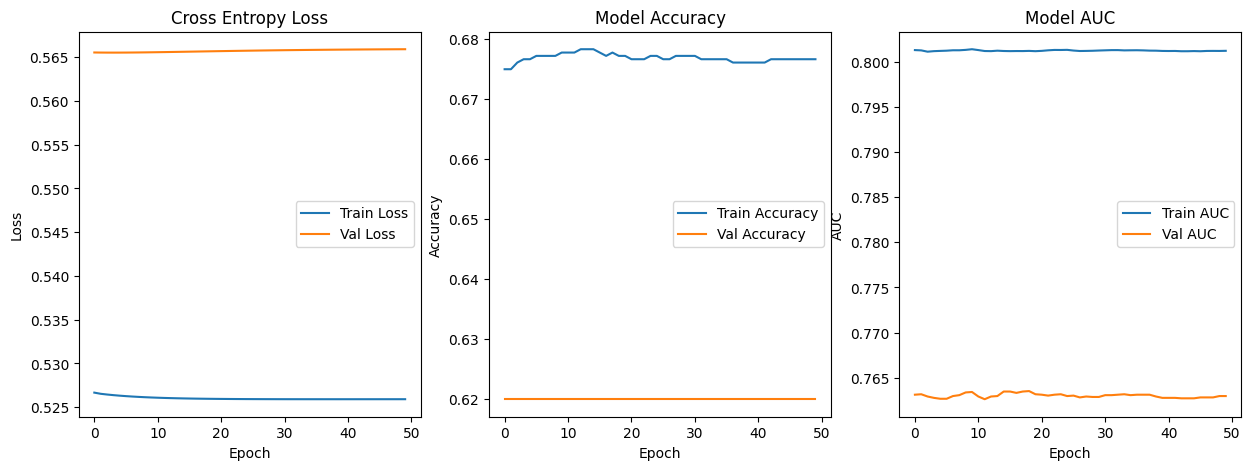

In [19]:
# Code for your answer here!
# 1. Compile the model
model_lr.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.AUC(name='auc')
    ]
)

# 2. Train the model
history = model_lr.fit(
    X, y,
    epochs=50,
    shuffle=True,
    validation_split=0.1
)

# 3. Plot metrics across epochs
history_dict = history.history

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Loss
ax[0].plot(history_dict['loss'], label='Train Loss')
ax[0].plot(history_dict['val_loss'], label='Val Loss')
ax[0].set_title('Cross Entropy Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy
ax[1].plot(history_dict['accuracy'], label='Train Accuracy')
ax[1].plot(history_dict['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

# AUC
ax[2].plot(history_dict['auc'], label='Train AUC')
ax[2].plot(history_dict['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()

plt.show()


### 🚩 Exercise 4 (CORE)

Draw a heatmap of the predicted probabilities. How does the model perform now?

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 619us/step


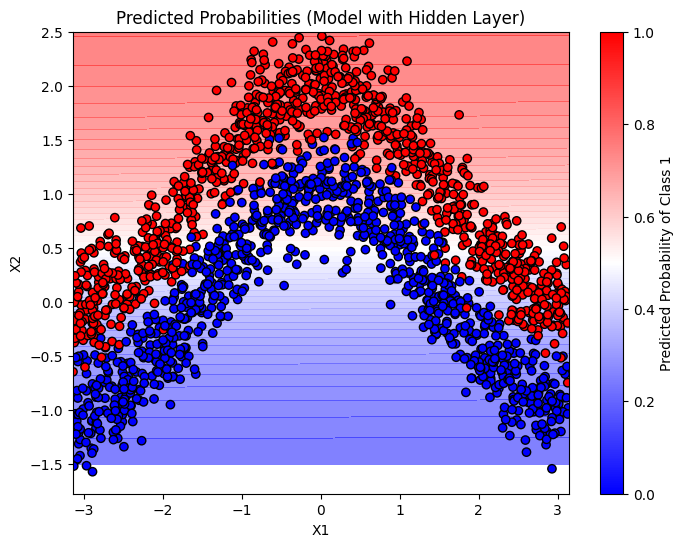

In [23]:
# Code for your answer here!
# Create a grid of test points
X_grid1, X_grid2 = np.meshgrid(
    np.linspace(-np.pi, np.pi, 200),
    np.linspace(-1.5, 2.5, 200)
)
X_grid = np.column_stack([X_grid1.ravel(), X_grid2.ravel()])

# Predict probabilities using the new model (with hidden layer)
y_pred_prob = model_lr.predict(X_grid)

# Draw heatmap
plt.figure(figsize=(8, 6))
plt.contourf(
    X_grid1, X_grid2,
    y_pred_prob.reshape(X_grid1.shape),
    levels=50, cmap='bwr', alpha=0.5
)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted Probabilities (Model with Hidden Layer)')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()


The model performs significantly better after adding a hidden layer.  
The heatmap now shows a non‑linear decision boundary that closely follows the true structure of the data. Unlike logistic regression, which can only learn a linear boundary, the neural network with a hidden layer is able to capture the curved shape created by the cosine-based data‑generating process.

The predicted probabilities transition smoothly between the two classes, and the boundary aligns well with the regions where the classes overlap. This indicates that the hidden layer successfully learned meaningful nonlinear features, improving both accuracy and AUC compared to the baseline logistic regression model.

Overall, the model now generalizes better and fits the underlying pattern of the data more effectively.

### Visualizing the output of each neuron

By visualizing the output of each neuron, we can gain an understanding of the features extracted. 

In the code below, we create a keras model for the mapping of the inputs to the hidden layer and pass through the data. By plotting the output of the hidden layer, we observe that:
- the first hidden feature captures the separation of the two classes when $x_1<0$ and 
- the second hidden feature captures the separation of the two classes when $x_1>0$.

In [24]:
# Extract the output of the hidden layer
hidden_layer_model = keras.Model(inputs=model_hidden2.input, outputs=model_hidden2.layers[1].output)

# Hidden output for the observed data
z =hidden_layer_model(X)
# Convert to numpy array
z = z.numpy()

# Hidden output for the test points
z_grid =hidden_layer_model(X_grid)
# Convert to numpy array
z_grid = z_grid.numpy()

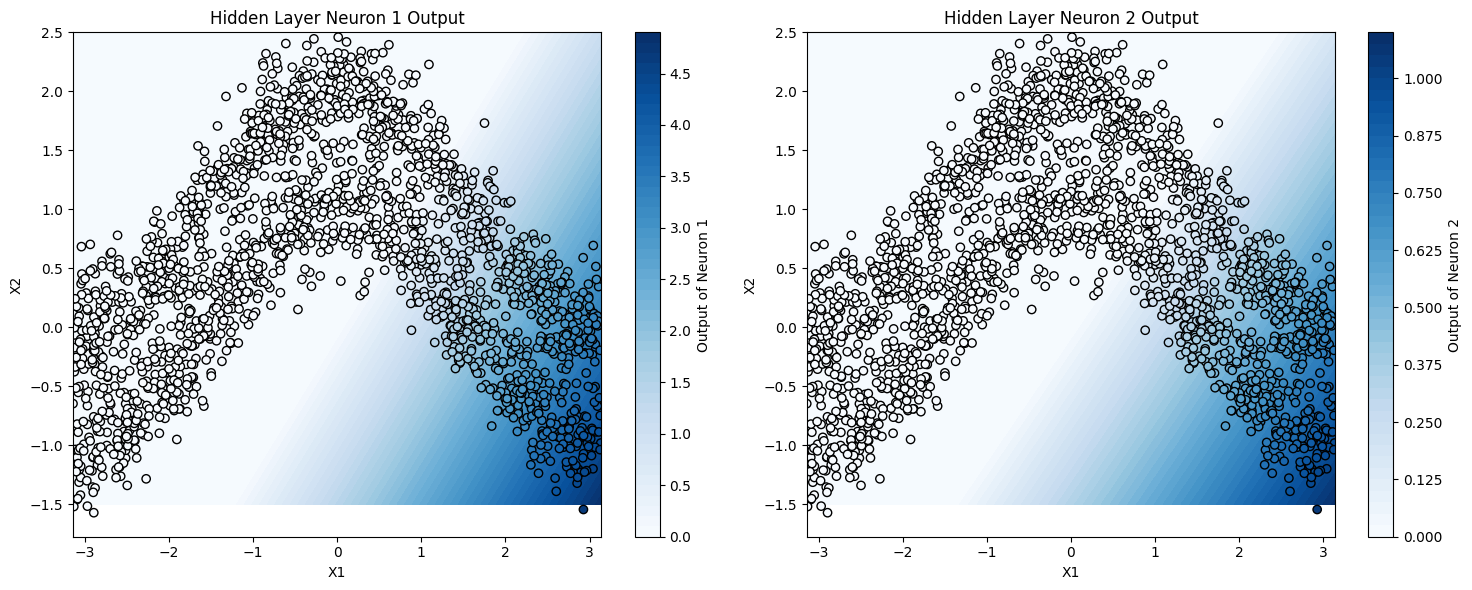

In [25]:
# Draw a heatmap of the output of the hidden layer neurons
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i in range(2):
    vmin= min(z[:,i].min(), z_grid[:,i].min())   
    vmax= max(z[:,i].max(), z_grid[:,i].max())
    ax[i].contourf(X_grid1, X_grid2, z_grid[:,i].reshape(X_grid1.shape), levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
    ax[i].scatter(X[:,0], X[:,1], c=z[:,i], cmap='Blues', edgecolor='k',vmin=vmin, vmax=vmax)
    ax[i].set_xlabel('X1')
    ax[i].set_ylabel('X2')
    ax[i].set_title(f'Hidden Layer Neuron {i+1} Output')
    cbar = plt.colorbar(ax[i].collections[0], ax=ax[i])
    cbar.set_label(f'Output of Neuron {i+1}')
fig.tight_layout() 
plt.show()

We can also print out the values of the weights and bias for each layer:

In [26]:
print('Hidden layer bias:', model_hidden2.layers[1].bias.numpy())
print('Hidden layer weights:', model_hidden2.layers[1].kernel.numpy())
print('Output layer bias:', model_hidden2.layers[2].bias.numpy())
print('Output layer weights:', model_hidden2.layers[2].kernel.numpy())

Hidden layer bias: [0. 0.]
Hidden layer weights: [[ 1.1013311   0.23736107]
 [-0.94473404 -0.22645217]]
Output layer bias: [0.]
Output layer weights: [[-0.73201996]
 [-0.05694306]]


### Increasing the width of the network

### 🚩 Exercise 5 (CORE)

Now, try increasing the number of hidden units to 5.
- Define and compile the model.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit over the grid of input values.

Comment on how the predictions have changed and what features appear to be extracted by each hidden unit. Which model would you choose and why?

In [27]:
# Code for your answer here!
# Define the model with 5 hidden units
input_layer = keras.layers.Input(shape=(2,))
hidden = keras.layers.Dense(5, activation='tanh')(input_layer)
output_layer = keras.layers.Dense(1, activation='sigmoid')(hidden)

model_5 = keras.models.Model(input_layer, output_layer)

# Compile
model_5.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.AUC(name='auc')
    ]
)

In [28]:
history_5 = model_5.fit(
    X, y,
    epochs=80,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4578 - auc: 0.3607 - loss: 0.7234 - val_accuracy: 0.4800 - val_auc: 0.4851 - val_loss: 0.6962
Epoch 2/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5372 - auc: 0.5838 - loss: 0.6824 - val_accuracy: 0.5700 - val_auc: 0.7642 - val_loss: 0.6658
Epoch 3/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6500 - auc: 0.8300 - loss: 0.6496 - val_accuracy: 0.6600 - val_auc: 0.8286 - val_loss: 0.6401
Epoch 4/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7172 - auc: 0.8431 - loss: 0.6220 - val_accuracy: 0.7000 - val_auc: 0.8063 - val_loss: 0.6186
Epoch 5/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7161 - auc: 0.8343 - loss: 0.5991 - val_accuracy: 0.6850 - val_auc: 0.7958 - val_loss: 0.6015
Epoch 6/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7089 - auc: 0.8295 - loss: 0.5807 - val_accuracy: 0.6700 - val_auc: 0.7929 - val_loss: 0.5883
Epoch 7/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step -

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 677us/step


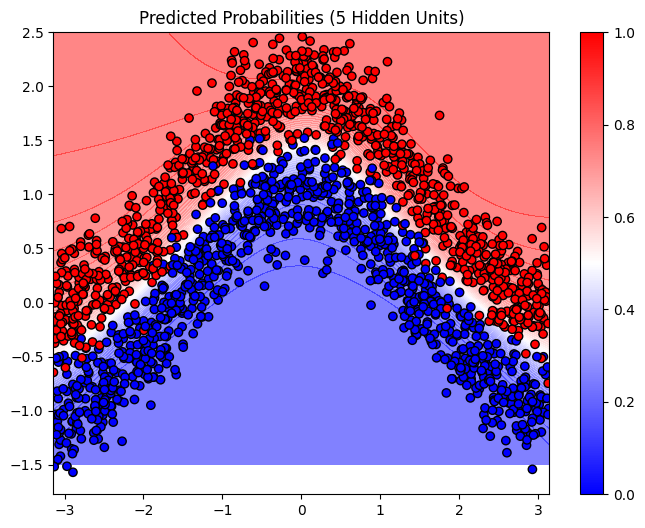

In [ ]:
# Create grid
Xg1, Xg2 = np.meshgrid(
    np.linspace(-np.pi, np.pi, 200),
    np.linspace(-1.5, 2.5, 200)
)
X_grid = np.column_stack([Xg1.ravel(), Xg2.ravel()])

# Predict
y_prob = model_5.predict(X_grid)

# Plot heatmap
plt.figure(figsize=(8,6))
plt.contourf(Xg1, Xg2, y_prob.reshape(Xg1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.title("Predicted Probabilities (5 Hidden Units)")
plt.colorbar()
plt.show()

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step


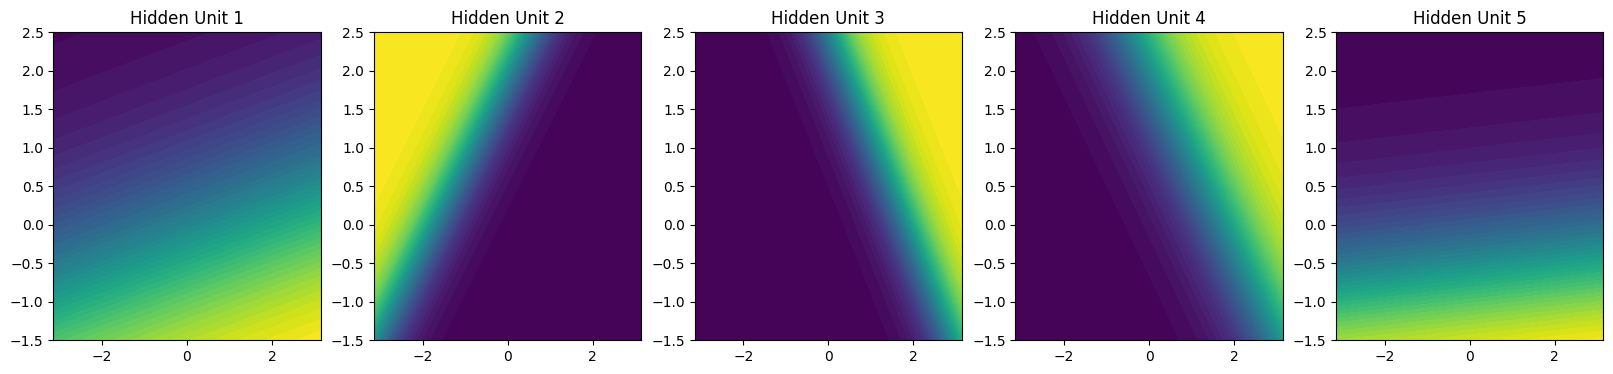

In [30]:
# Model that outputs hidden layer activations
hidden_model = keras.models.Model(inputs=model_5.input, outputs=hidden)

hidden_outputs = hidden_model.predict(X_grid)

# Plot each hidden unit
fig, axes = plt.subplots(1, 5, figsize=(20,4))

for i in range(5):
    axes[i].contourf(
        Xg1, Xg2,
        hidden_outputs[:, i].reshape(Xg1.shape),
        levels=50, cmap='viridis'
    )
    axes[i].set_title(f"Hidden Unit {i+1}")

After increasing the width of the network to 5 hidden units, the model becomes more flexible and is able to learn a richer set of nonlinear features. The predicted‑probability heatmap shows a smoother and more accurate approximation of the true decision boundary compared to the previous models.

Each hidden unit appears to extract a different nonlinear feature of the data. Some units capture the curvature of the cosine‑based structure, while others focus on separating regions where the classes overlap. Together, these units combine to form a more expressive representation of the input space.

Overall, the wider model performs better because it can approximate the complex underlying pattern more effectively. I would choose the model with 5 hidden units because it provides a better balance between flexibility and interpretability, and it produces a decision boundary that closely matches the true data‑generating process.

### Increasing the depth of the network

### 🚩 Exercise 6 (CORE)

Now, consider a model with two layers: 5 hidden units in the first layer and 2 hidden units in the second layer.
- Define and compile the model.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit (in both layers) over the grid of input values.

Comment on how the predictions have changed and differences in the features extracted by the second layer compared to the first. Which model would you choose and why?

In [31]:
# Code for your answer here!
# Define the model with two hidden layers
input_layer = keras.layers.Input(shape=(2,))

hidden1 = keras.layers.Dense(5, activation='tanh')(input_layer)
hidden2 = keras.layers.Dense(2, activation='tanh')(hidden1)

output_layer = keras.layers.Dense(1, activation='sigmoid')(hidden2)

model_6 = keras.models.Model(input_layer, output_layer)

# Compile
model_6.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.AUC(name='auc')
    ]
)

In [32]:
history_6 = model_6.fit(
    X, y,
    epochs=80,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5506 - auc: 0.7121 - loss: 0.6803 - val_accuracy: 0.5050 - val_auc: 0.6966 - val_loss: 0.6739
Epoch 2/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6211 - auc: 0.7332 - loss: 0.6276 - val_accuracy: 0.6400 - val_auc: 0.7059 - val_loss: 0.6333
Epoch 3/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6778 - auc: 0.7661 - loss: 0.5962 - val_accuracy: 0.6400 - val_auc: 0.7380 - val_loss: 0.6143
Epoch 4/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6561 - auc: 0.7928 - loss: 0.5800 - val_accuracy: 0.6150 - val_auc: 0.7534 - val_loss: 0.6035
Epoch 5/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6594 - auc: 0.8025 - loss: 0.5690 - val_accuracy: 0.6100 - val_auc: 0.7620 - val_loss: 0.5952
Epoch 6/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6656 - auc: 0.8089 - loss: 0.5601 - val_accuracy: 0.6150 - val_auc: 0.7688 - val_loss: 0.5878
Epoch 7/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - 

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step


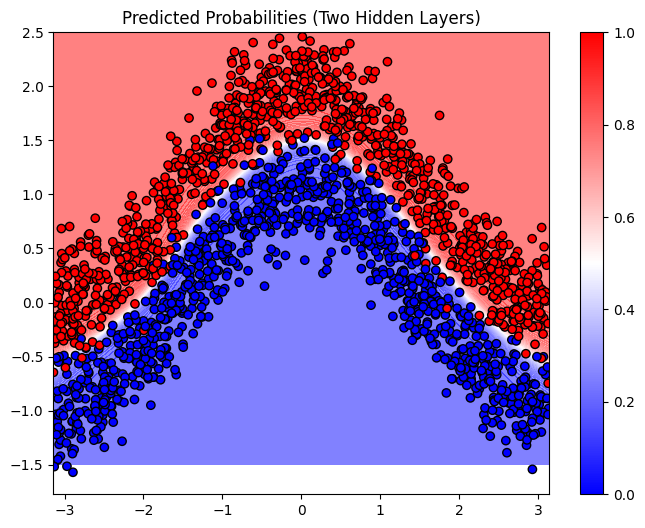

In [33]:
# Create grid
Xg1, Xg2 = np.meshgrid(
    np.linspace(-np.pi, np.pi, 200),
    np.linspace(-1.5, 2.5, 200)
)
X_grid = np.column_stack([Xg1.ravel(), Xg2.ravel()])

# Predict
y_prob = model_6.predict(X_grid)

# Plot heatmap
plt.figure(figsize=(8,6))
plt.contourf(Xg1, Xg2, y_prob.reshape(Xg1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.title("Predicted Probabilities (Two Hidden Layers)")
plt.colorbar()
plt.show()

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 626us/step


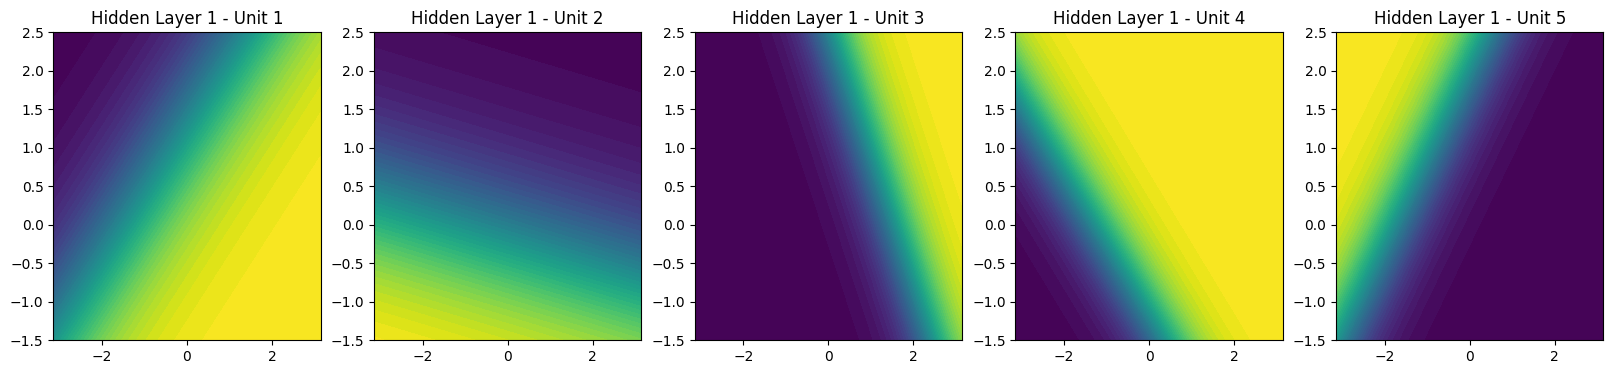

In [34]:
hidden1_model = keras.models.Model(inputs=model_6.input, outputs=hidden1)
hidden1_out = hidden1_model.predict(X_grid)

fig, axes = plt.subplots(1, 5, figsize=(20,4))
for i in range(5):
    axes[i].contourf(
        Xg1, Xg2,
        hidden1_out[:, i].reshape(Xg1.shape),
        levels=50, cmap='viridis'
    )
    axes[i].set_title(f"Hidden Layer 1 - Unit {i+1}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step


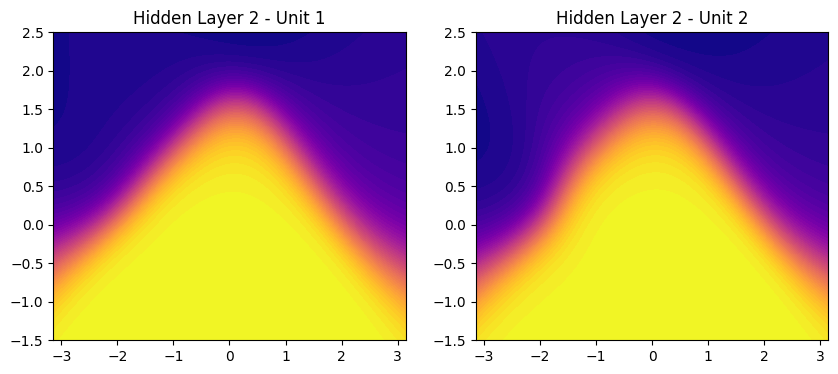

In [35]:
hidden2_model = keras.models.Model(inputs=model_6.input, outputs=hidden2)
hidden2_out = hidden2_model.predict(X_grid)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
for i in range(2):
    axes[i].contourf(
        Xg1, Xg2,
        hidden2_out[:, i].reshape(Xg1.shape),
        levels=50, cmap='plasma'
    )
    axes[i].set_title(f"Hidden Layer 2 - Unit {i+1}")

The model with two hidden layers produces a smoother and more structured decision boundary compared to the previous models. The first hidden layer (5 units) extracts several nonlinear features that capture different curved regions of the input space. Each unit focuses on a different part of the cosine‑based structure.

The second hidden layer (2 units) combines these features into higher‑level representations. Instead of detecting simple curves, these units learn more abstract patterns that help refine the final decision boundary. This results in a more accurate and flexible model.

Compared to the single‑layer model, the deeper model captures more complex interactions and produces a cleaner separation between the classes. I would choose the two‑layer model because it generalizes better and learns richer nonlinear features while still remaining relatively small and interpretable.

### Changing the activation function

### 🚩 Exercise 7 (EXTRA)

Next, let's explore changing the activation function. 

- Define and compile with your choice of width and depth (number of layers and number of hidden units within each layer), but consider a different activation function for the hidden layer, namely `tanh`.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit over the grid of input values.

Comment on how the predictions have changed and differences in the features extracted when using the `tanh` activation function instead of the `relu` activation.

In [ ]:
# Code for your answer here!

_Type your answer here_ 

# Part 2: MNIST Data

### Loading, exploring, and preparing the data

For the second part, we are going to use the MNIST dataset, partly because you are already familiar with it, and partly because it comes with tensorflow, the most widely used library for neural networks in python.

Let's start by load the MNIST data using `keras.datasets.mnist.load_data()`

In [40]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)



Let's display the six images in the training set.

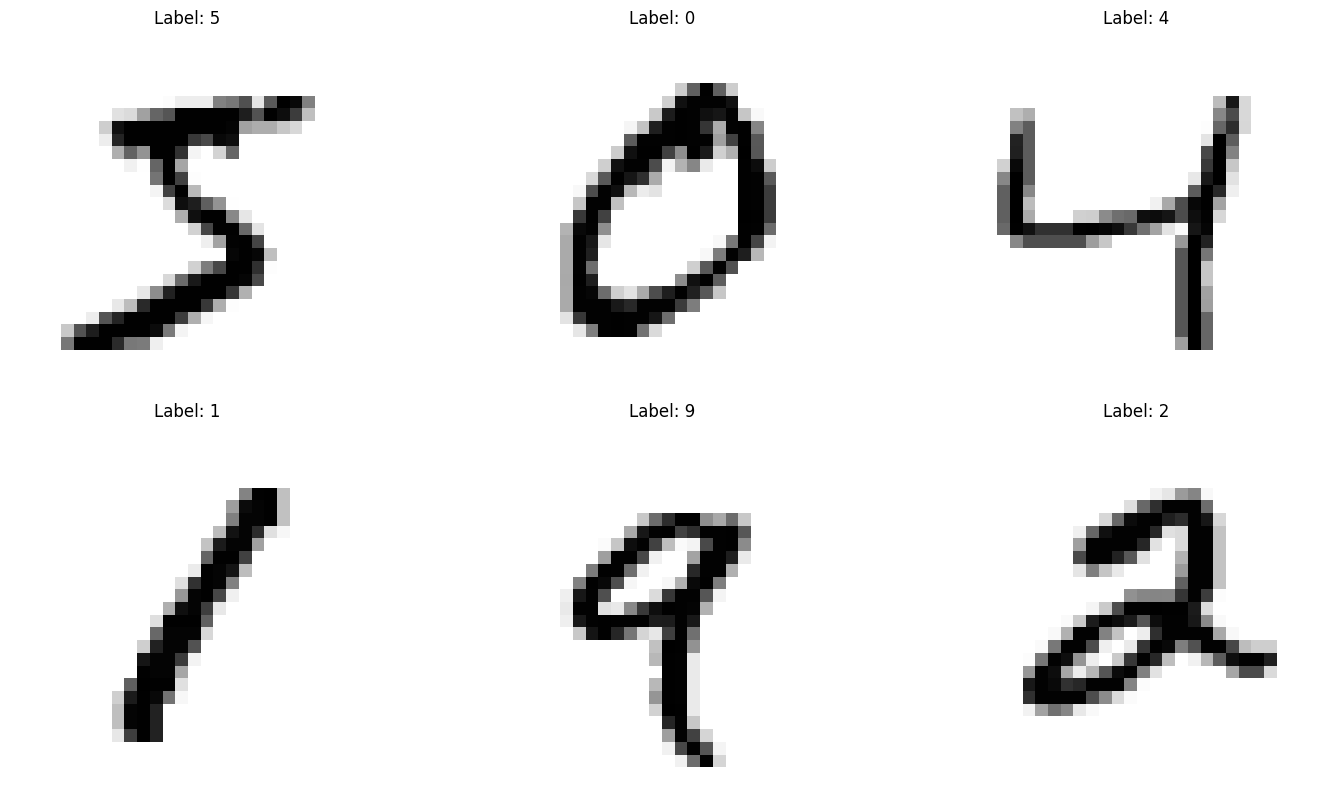

In [41]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.flatten()
for i in range(6):
    ax[i].imshow(X_train[i], cmap="gray_r")
    ax[i].set_title(f"Label: {y_train[i]}")
    ax[i].axis('off')
fig.tight_layout()
plt.show()

Next, we divide the features by 255 (the maximum value of the pixels), so that all pixel values in the training and testing data are between 0 and 1. 

In the workshop, we will be working only with fully connected feed-forward networks (that don't exploit the spatial structure of the images like convolutional neural networks). As such, we also flatten all images to vectors.

In [42]:
# Rescale the data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape the data 
X_train = X_train.reshape((-1, 28 * 28))
X_test = X_test.reshape((-1, 28 * 28))

Lastly, we use convert the labels using a `LabelEncoder`.

In [43]:
# Converting the labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

### 🚩 Exercise 8 (CORE)

As a baseline model, create a pipeline (called `baseline`) that
- first uses PCA to reduce the dimension to 100
- then uses logistic regression with no penalty

Fit the pipeline to the data. Plot the confusion matrix and print the classification report. How many parameters does the logistic regression model have?

In [44]:
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss

# Code for your answer here
baseline = make_pipeline(
    PCA(n_components=100),
    LogisticRegression(max_iter=2000)
)

In [45]:
baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pca', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",100
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver 

In [46]:
y_test_pred = baseline.predict(X_test)

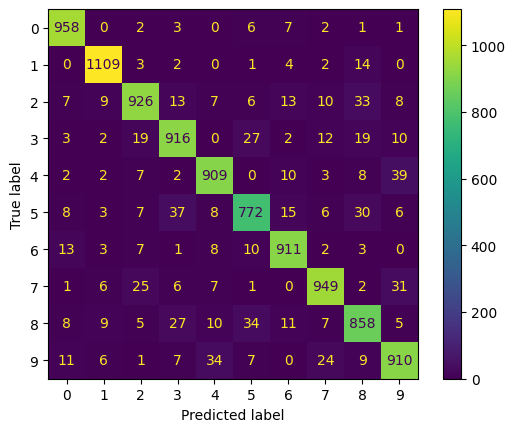

In [47]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.show()

In [48]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.92      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.92      0.93      0.93       982
           5       0.89      0.87      0.88       892
           6       0.94      0.95      0.94       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.90      0.90      0.90      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



Let's plot some of the images that were both correctly and incorrectly classified, along with the corresponding probabilities. 

Note: if you have called your model something other than `baseline`, please change the name in the code below.

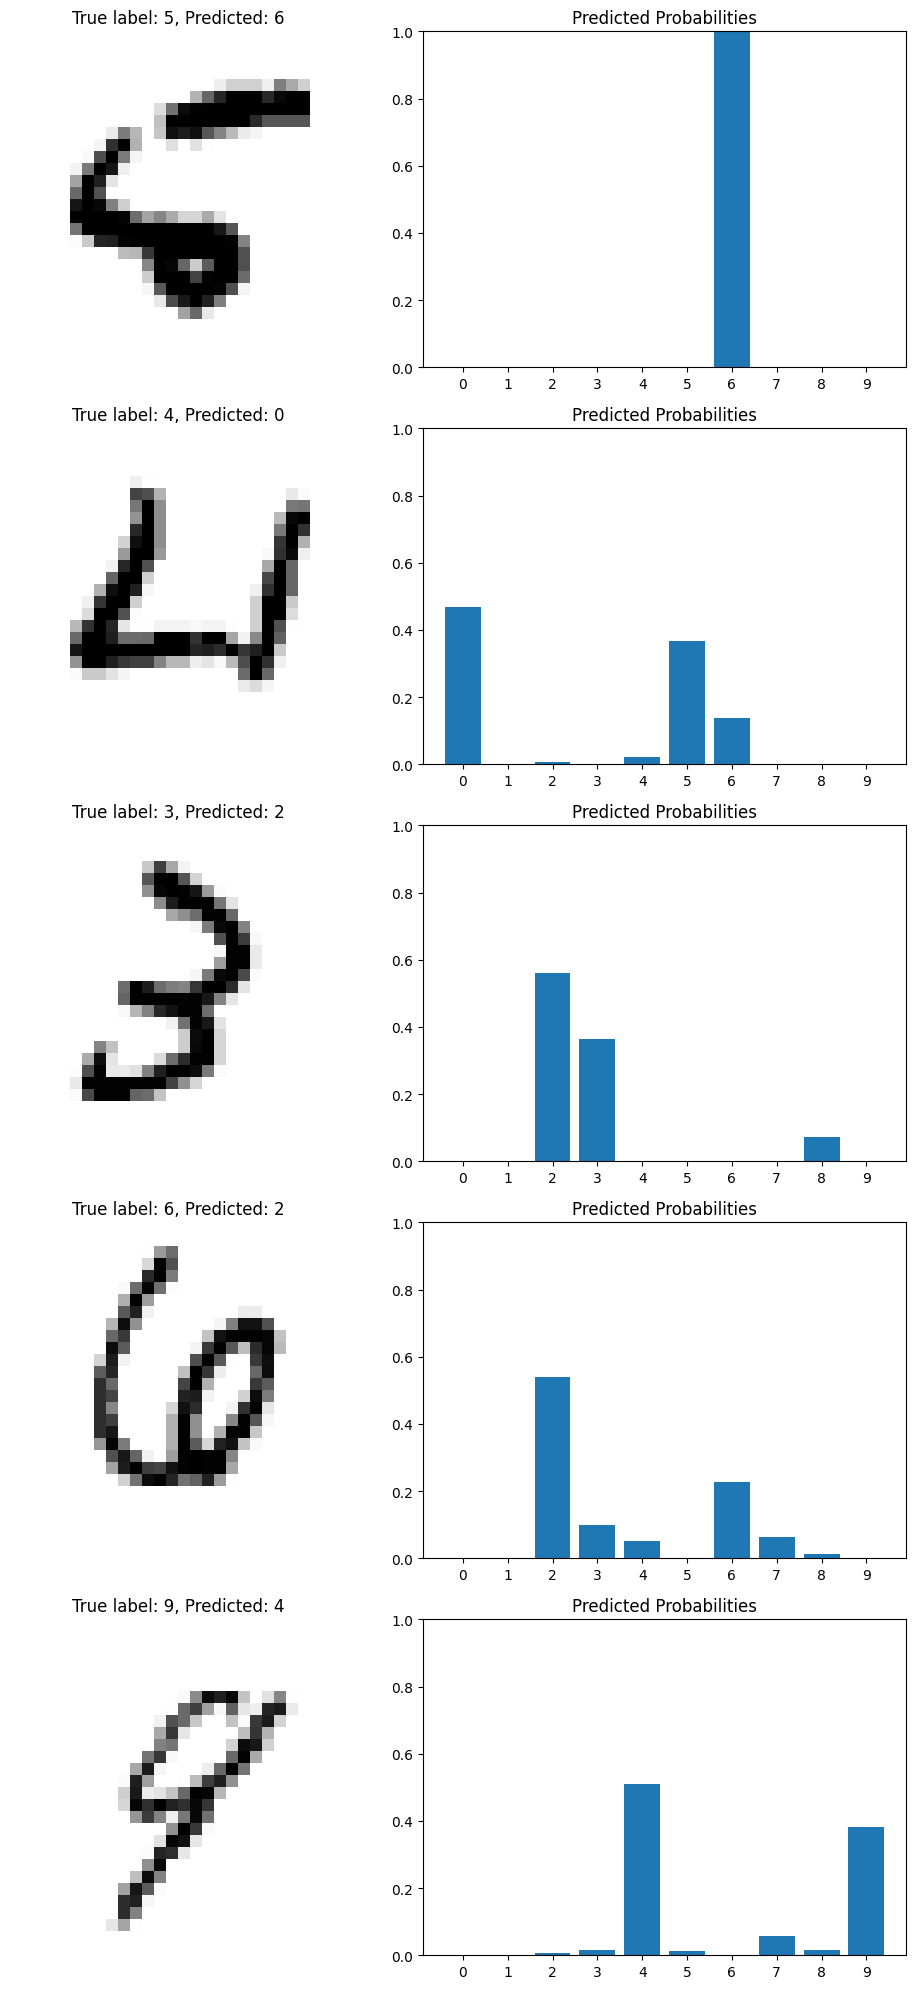

In [49]:
# indices of misclassified examples
misclas_indices = np.where(y_test != y_test_pred)[0]
# indices of correctly classified examples
clas_indices = np.where(y_test == y_test_pred)[0]

# For the first 5 misclassified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = misclas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = baseline.predict_proba(X_test[idx].reshape(1, -1))[0]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

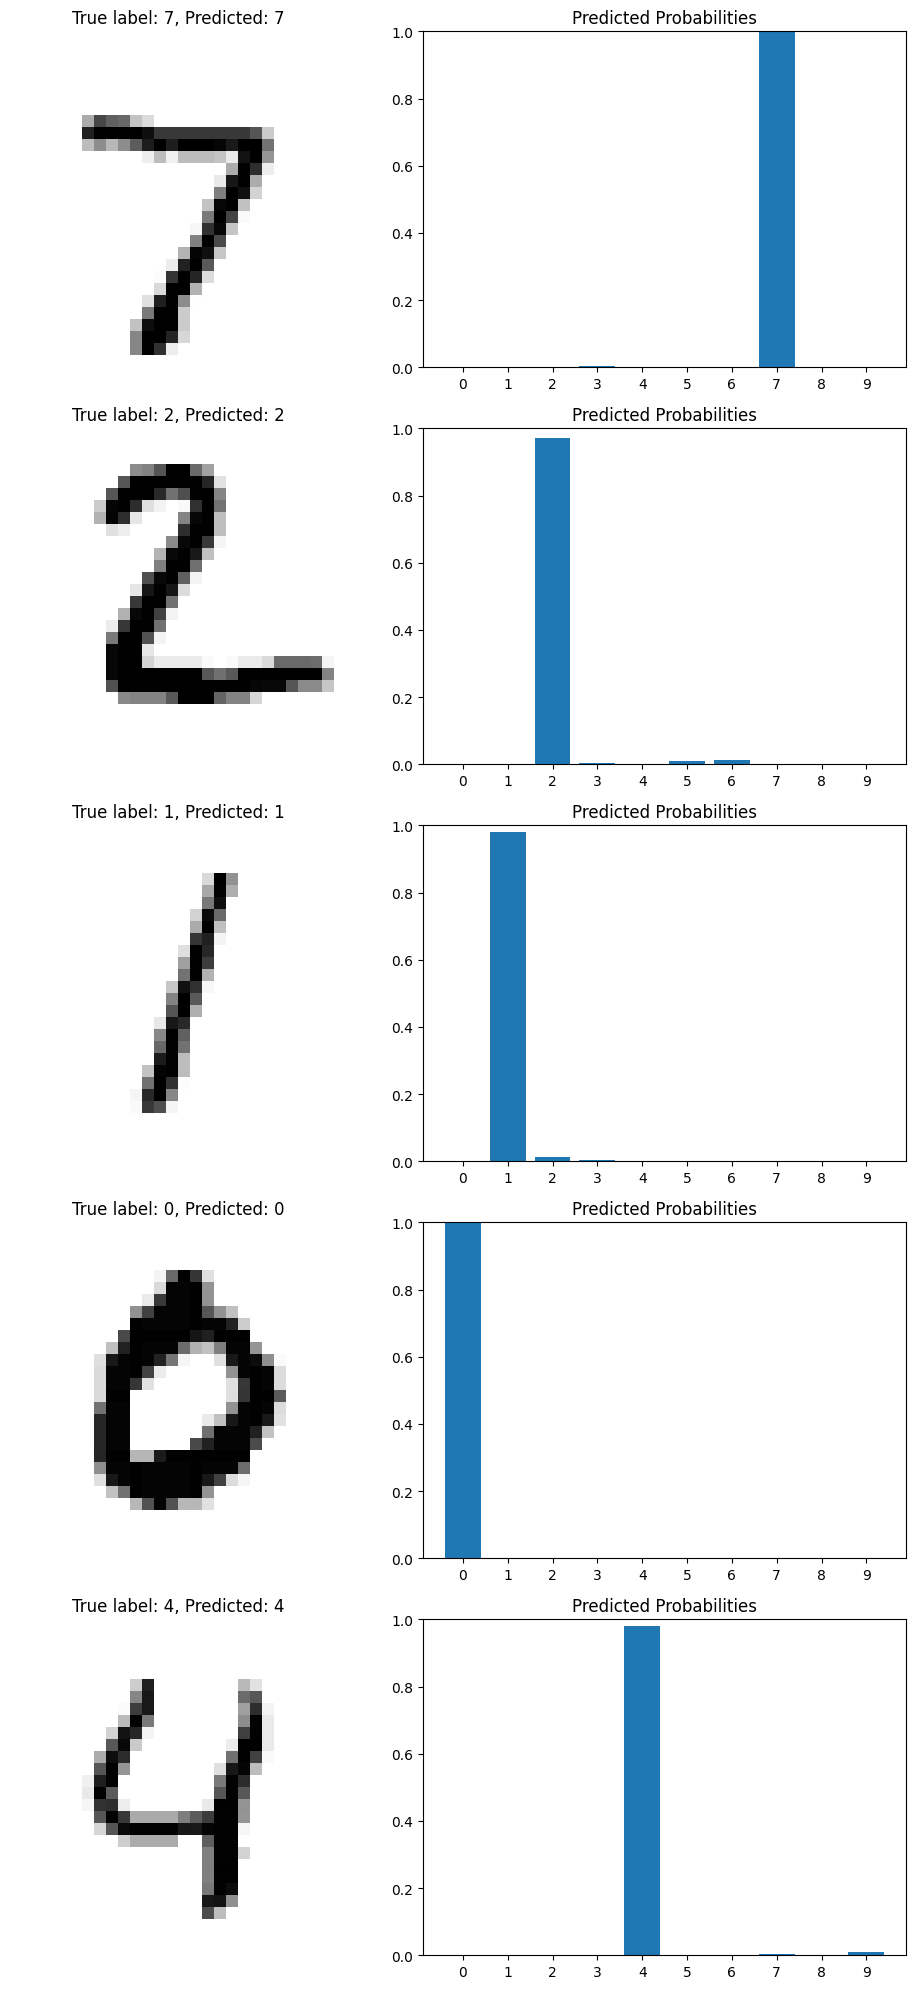

In [50]:
# For the first 5 correctly classified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = clas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = baseline.predict_proba(X_test[idx].reshape(1, -1))[0]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

It can be concerning when we have high probability/confidence for incorrectly classified images. This is quantified across all data points by the cross entropy loss, which for a single data points computes:

$$ L(y, p) = \sum_{c=1}^C y_c\log(p_c).$$

Notice that if the probability of the true class is close to 1, than the loss is zero, but if it is close to zero that the loss is high. 

We can report the cross entropy loss, averaged across all data points. 

In addition, through histogram showing the distribution of the probability of that $y$ is equal to the true test label, we can gain a more detailed understanding. We see that for the correctly classified images, over 4,000 images are correctly classified with a high probability. On the other hand, there are over 100 images that are misclassified with a high probability. 

Cross entropy loss: 0.2798363872010599


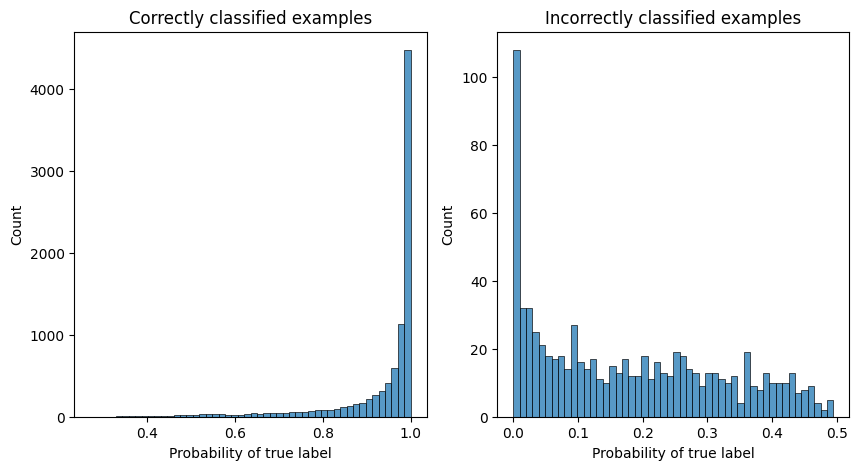

In [51]:
y_test_pred_prob = baseline.predict_proba(X_test)
print('Cross entropy loss:', log_loss(y_test, y_test_pred_prob, labels=label_encoder.classes_))

# Extract probabilility of correct label for each data point
prob_correct = y_test_pred_prob[np.arange(len(y_test)), y_test]

# Plot a histogram of the probabilities across data points, for correct or incorrect classification
fig, ax = plt.subplots(1,2,figsize = (10,5))
sns.histplot(x = prob_correct[clas_indices], bins=50, ax=ax[0])
ax[0].set_title('Correctly classified examples')
ax[0].set_xlabel('Probability of true label')
sns.histplot(x = prob_correct[misclas_indices], bins=50, ax=ax[1])
ax[1].set_xlabel('Probability of true label')
ax[1].set_title('Incorrectly classified examples')
plt.show()

### 🚩 Exercise 9 (CORE)

Next, let's fit a fully-connected feed forwared neural network. Note that we need to one-hot encoding the output labels for use in keras in the multiclass setting.

- Define and compile a model with one hidden layer of 128 neurons and ReLU activation. For the final layer, use a softmax with 10 units to obtain the probabilities for each class. Here use the categorical cross entropy loss. 
- Fit the model and train for 10 epochs with a batch size of 128 and a 10% validation split, and plot the loss and accuracy for the training and validation sets as a function of epochs.
- Plot the confusion matrix and print the classification report on the test data.
- Visualize some the test images, along with their probabilities for both correctly and incorrectly classified images.
- Print the cross entropy loss on the test data, and visualize the distribution of the probability of the true labels for correctly and incorrectly classified test points.

In [52]:
# First create a one-hot encoding of the labels for use in Keras
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)
# Print the first few rows before and after one-hot encoding
print("Original labels:", y_train[:5])
print("One-hot encoded labels:\n", y_train_cat[:5])

Original labels: [5 0 4 1 9]
One-hot encoded labels:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [53]:
# Code for your answer here!
model = keras.models.Sequential([
    keras.layers.Input(shape=(784,)),   # لأن الصور 28x28 = 784
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [54]:
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8925 - loss: 0.3866 - val_accuracy: 0.9530 - val_loss: 0.1721
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9486 - loss: 0.1795 - val_accuracy: 0.9663 - val_loss: 0.1257
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9627 - loss: 0.1301 - val_accuracy: 0.9692 - val_loss: 0.1069
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9710 - loss: 0.1012 - val_accuracy: 0.9727 - val_loss: 0.0978
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9767 - loss: 0.0816 - val_accuracy: 0.9740 - val_loss: 0.0918
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9810 - loss: 0.0674 - val_accuracy: 0.9743 - val_loss: 0.0882
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9845 - loss: 0.0564 - val_accuracy: 0.9740 - val_loss: 0.0872
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9876 - loss: 0.0471 - val_accuracy: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


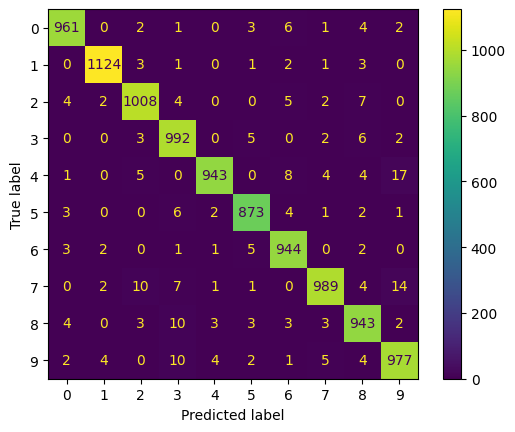

In [55]:
y_test_pred = model.predict(X_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_labels)
plt.show()

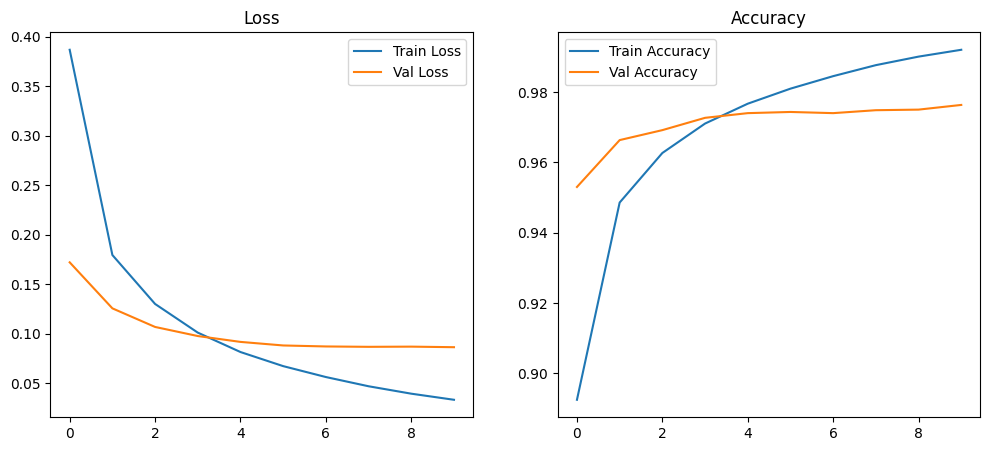

In [56]:
history_dict = history.history

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Loss
ax[0].plot(history_dict['loss'], label='Train Loss')
ax[0].plot(history_dict['val_loss'], label='Val Loss')
ax[0].set_title('Loss')
ax[0].legend()

# Accuracy
ax[1].plot(history_dict['accuracy'], label='Train Accuracy')
ax[1].plot(history_dict['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Accuracy')
ax[1].legend()

plt.show()

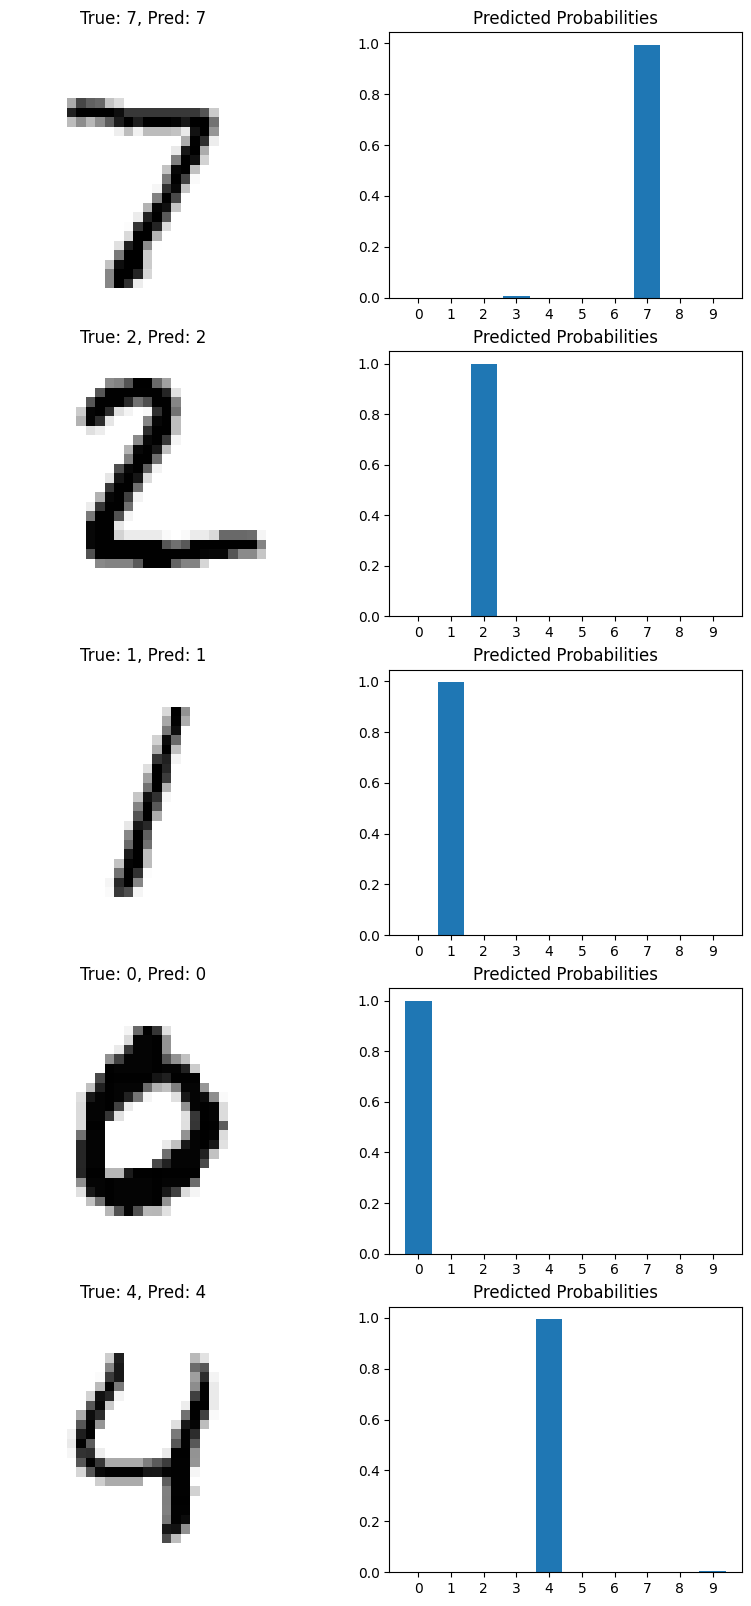

In [57]:
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = i
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f"True: {y_test[idx]}, Pred: {y_test_pred_labels[idx]}")
    ax[i, 0].axis('off')

    ax[i, 1].bar(range(10), y_test_pred[idx])
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_title("Predicted Probabilities")
plt.show()

In [58]:
print("Cross entropy loss:", log_loss(y_test_cat, y_test_pred))

Cross entropy loss: 0.08227849423490799


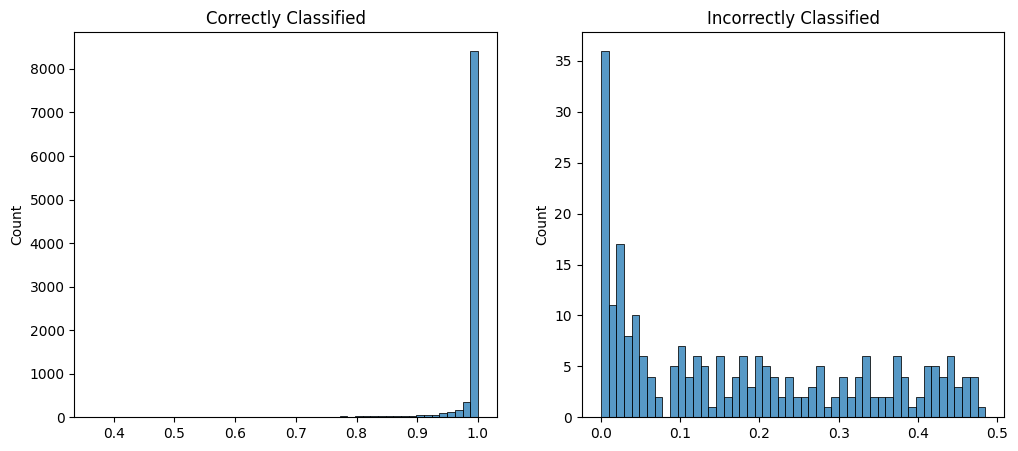

In [59]:
prob_correct = y_test_pred[np.arange(len(y_test)), y_test]

correct_idx = np.where(y_test == y_test_pred_labels)[0]
incorrect_idx = np.where(y_test != y_test_pred_labels)[0]

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(prob_correct[correct_idx], bins=50, ax=ax[0])
ax[0].set_title("Correctly Classified")

sns.histplot(prob_correct[incorrect_idx], bins=50, ax=ax[1])
ax[1].set_title("Incorrectly Classified")

plt.show()

### 🚩 Exercise 10 (CORE)

Comment on the following:

a. Do you think you need to train the model for more epochs? 

b. Which model do you prefer: the baseline logisitic regression or the neural network? Consider the trade-off between: the number of parameters and predictive performance.

a. Based on the training and validation curves, the model does not seem to benefit much from additional epochs. The training and validation losses have largely stabilized, and the validation accuracy is no longer improving substantially. If we continue training for many more epochs, there is a risk of overfitting without a meaningful gain in performance. Therefore, training for more epochs does not appear strictly necessary, unless we observe clear signs that the validation metrics are still consistently improving.

b.I would prefer the neural network model. Although it has more parameters than the baseline logistic regression, it achieves better predictive performance by capturing nonlinear patterns in the data that logistic regression cannot model. The improvement in accuracy and cross‑entropy loss suggests that the additional complexity is justified. However, if model simplicity, interpretability, or computational cost were the main priorities, the logistic regression model could still be a reasonable choice. In this setting, the trade‑off favors the neural network because the gain in performance outweighs the increase in the number of parameters.

### 🚩 Exercise 11 (EXTRA)

Let's explore a deeper architecture.

- Build a deeper network with three hidden layers, with $D_1 = 128, D_2 = 64, D_1 = 32$ neurons and ReLU activation, and an output layer with 10 neurons and softmax activation.

- Compile and train the model with the same setting as the shallow model.

- Plot the loss and accuracy for the training and validation sets as a function of epochs. Do you think more epochs are needed?

- Plot the confusion matrix, print the classification report, and cross entropy loss. Visualize some the images, along with their probabilities for both correctly and incorrectly classified images.

- Which model do you prefer? Consider the trade-off between: the number of parameters and predictive performance.

In [ ]:
# Code for your answer here!

_Type your answer here_

# Completing the Worksheet

At this point you have hopefully been able to complete all the CORE exercises and attempted the EXTRA ones. Now 
is a good time to check the reproducibility of this document by restarting the notebook's
kernel and rerunning all cells in order.


Before generating the PDF, please **change 'Student 1' and 'Student 2' at the top of the notebook to include your name(s)**.

Once that is done and you are happy with everything, you can then run the following cell 
to generate your PDF. Once generated, please submit this PDF on Learn page by 16:00 PM on the Friday of the week the workshop was given. 

In [ ]:
!jupyter nbconvert --to pdf mlp_week09.ipynb 